In [8]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import z_agn_pivot
from hubble_fit import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
df_agn, df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = hubble_fit.load_data("results/data/aug12_chisq_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False)


Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 2160/2160 [00:06<00:00, 309.50it/s]


Number of quasars loaded: 2160
Length of colin_df: 5189
Number with apparent_mag_2500 > 0: 4335
Length of merged DataFrame: 2183
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 522
Number of quasars with z > 3: 58
Highest redshift quasar: 3.922086715698242
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Cut on alpha_lambda: 101 objects removed
Cut on redchi: 6 objects removed
Cut on apparent_mag_2500: 361 objects removed
Cut on apparent_mag_i: 18 objects removed
Total objects removed by all cuts: 482
Number of quasars with 0 < z <= 1.0: 403
Number of dropped quasars with 0 < z <= 1.0: 119
Number of quasars with z > 3: 37
Final number of quasars: 1678
Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Data loaded. 


In [6]:
import hubble_fit
cosmo_model = 'Flatw0waCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=False,resume=False)


Pivot point for x: 20.134418487548828
Using mag range: 16.00 to 26.00
log tau UV RF mean:  2.7415898698888235
log tau UV RF pivot:  2.707226552875453
log sigma0 mean:  -0.7282590889631808
log sigma0 pivot:  -0.7261887097044297
z mean: 1.541,  z_agn_pivot: 1.449


2136it [05:24,  6.58it/s, batch: 1 | bound: 75 | nc: 1 | ncall: 71964 | eff(%):  2.962 | loglstar: 2754.335 < 4664.507 <    inf | logz: 3418.638 +/-  2.055 | stop: 10.000]          



Bayesian evidence logZ = 4634.05 ± 0.69

Highest-weight (posterior) sample:
  idx: 1558
  logl: 4657.949986242149
  weight: 0.003096715733052183
  (preview) log(integrals)[:10]: [-2.7665261  -1.83018357 -2.75041851 -2.8782337  -1.37708899 -2.14744536
 -1.54410202 -1.89752247 -3.27315892 -3.44824314]

Posterior (equal-weight) blob summaries:
  per-object mean (first 10): [-2.82508007 -1.85933263 -2.76106003 -2.95480469 -1.46190067 -2.08797517
 -1.58061393 -1.86434439 -3.2901632  -3.4844667 ]
  per-object median (first 10): [-2.82312808 -1.85909294 -2.76201657 -2.96227695 -1.46130295 -2.0874844
 -1.58072694 -1.86436977 -3.287775   -3.48518787]

Dynesty results stats:
  samples shape: (2136, 11)
  blobs shape: (2136, 1678)
  weights max: 0.003096715733052183
  effective samples (ESS): 461.760370919238
  resampled samples shape: (2136, 11)
  resampled blobs shape: (2136, 1678)

Median parameters (equal-weight posterior):
[-8.18869864e-03  1.16866126e-01 -1.92457709e+01 -2.22384474e+01
  4

/home/dutra/dev/eztaox/qvc/hubble_plotting.py:548: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


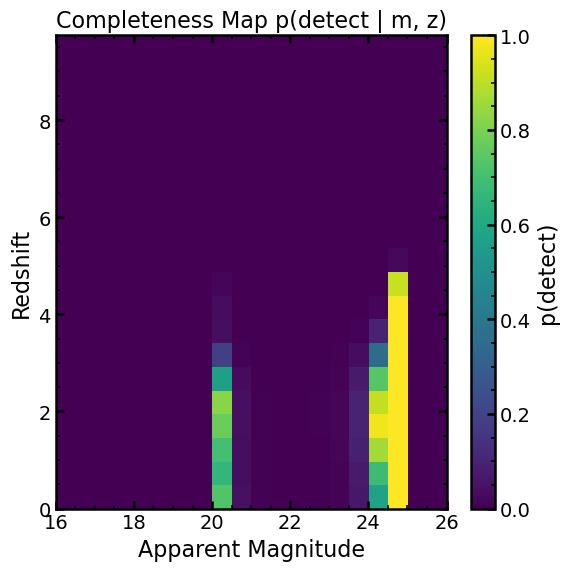

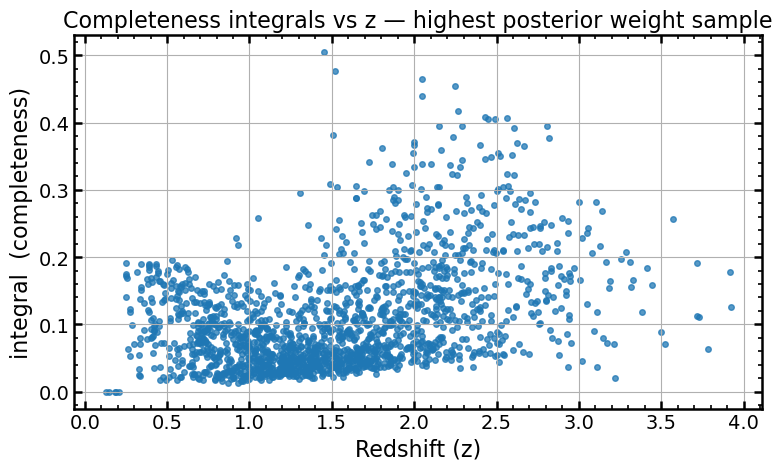

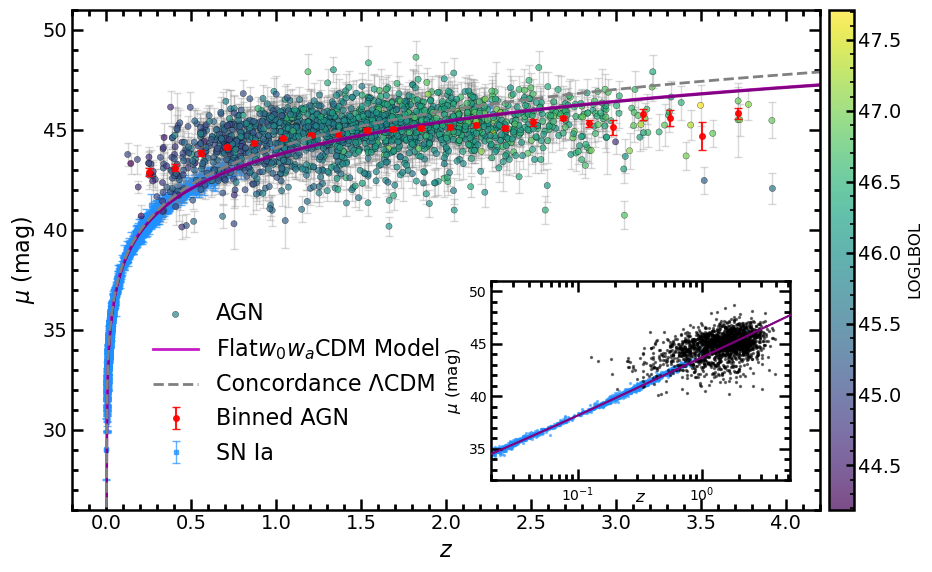

In [9]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, show_true=False)

Reduced chi^2: 9.508


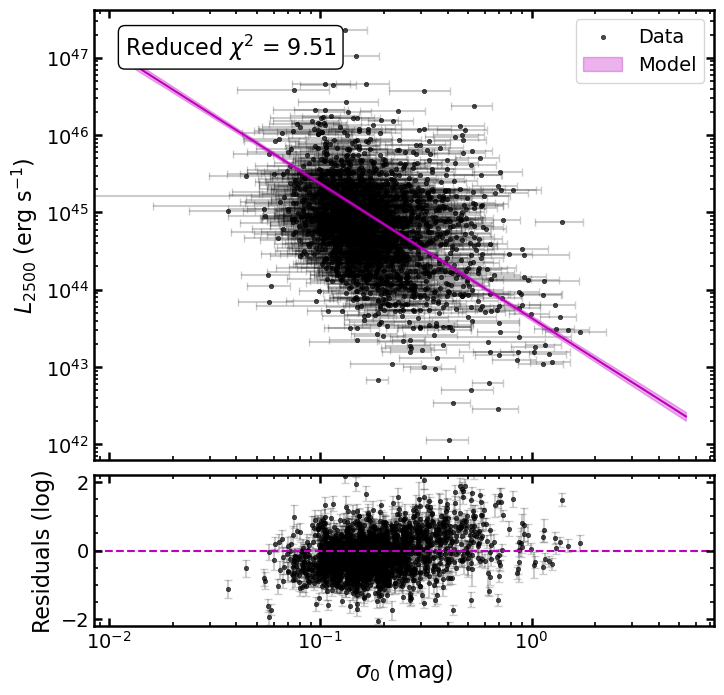

In [10]:
from hubble_plotting import plot_predicted_L2500_vs_sigmahat

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)

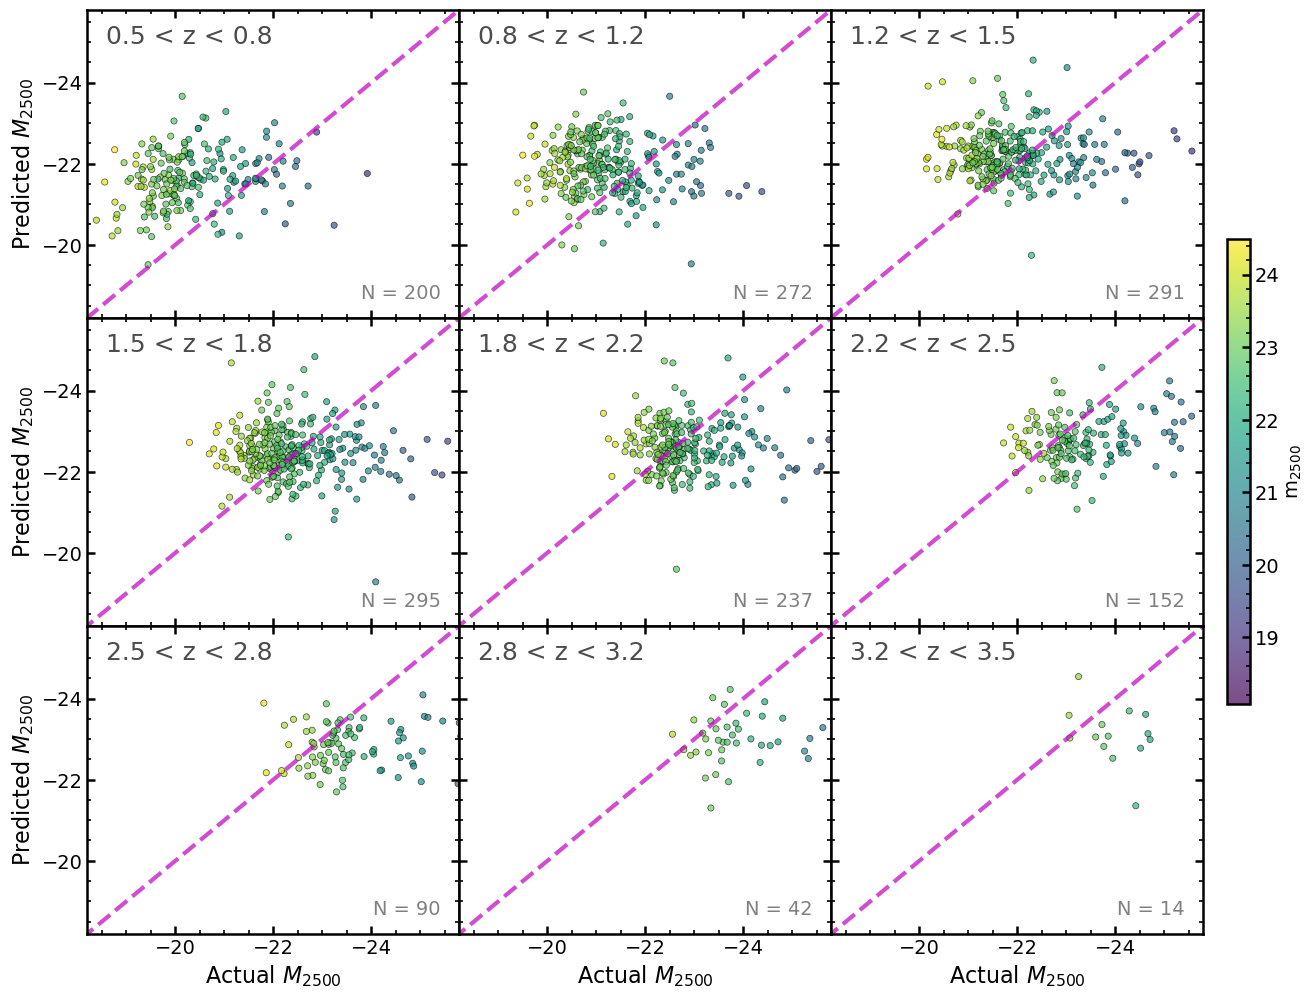

In [12]:
from hubble_plotting import plot_predicted_vs_actual_M2500

plot_predicted_vs_actual_M2500(flat_samples, df_agn, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True)